# Stage 1 — The GenAI Augmentation Paradox Under Compute Constraints

## 1. Introduction

This notebook implements the **Stage 1 Proof of Concept** for our Tiny ImageNet classification project. We investigate whether synthetic images from pretrained diffusion models can recover performance lost in low-data regimes, and whether any apparent recovery reflects genuine representation improvement rather than trivial data smoothing.

**Three pipelines:**
1. **Baseline** — 5% real Tiny ImageNet + classical augmentations  
2. **DiffusionBoost** — 5% real + class-conditional synthetic samples from Stable Diffusion  
3. **Ceiling** — 100% real Tiny ImageNet  

**Stage 1 deliverables:**
- Data loading and EDA on a 5% stratified subset (5,000 images)
- Baseline training with pretrained ResNet-18 for 5 epochs
- Initial metrics: accuracy, calibration (ECE), corruption robustness, and representation analysis

In Stage 2, we will extend this pipeline with diffusion-generated synthetic data and investigate whether the benefit of augmentation is uniform across classes — with implications for how synthetic data should be generated and allocated under compute constraints.

In [ ]:
# ---- Environment setup (Colab / Local auto-detect) ----
import os

IN_COLAB = "COLAB_GPU" in os.environ or os.path.exists("/content")

if IN_COLAB:
    import subprocess, sys
    for pkg in ["matplotlib", "seaborn", "scikit-learn", "tqdm"]:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
    print("Running in Google Colab — dependencies installed.")
else:
    print("Running locally.")

In [2]:
import os, sys, random, csv
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---- Device ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU:    {torch.cuda.get_device_name()}")
    print(f"VRAM:   {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ---- Paths (auto-detect Colab vs local) ----
if IN_COLAB:
    PROJECT_ROOT = Path("/content/cv_project")
else:
    PROJECT_ROOT = Path("..").resolve()

DATA_ROOT = PROJECT_ROOT / "data"
TINY_IMAGENET_ROOT = DATA_ROOT / "raw" / "tiny-imagenet-200"
SUBSET_INDEX = DATA_ROOT / "tiny_imagenet_5pct" / "train_index.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"

for d in [DATA_ROOT, FIGURES_DIR, CHECKPOINTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- Constants ----
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
BATCH_SIZE    = 64
NUM_WORKERS   = 0   # 0 for Windows notebook compatibility
EPOCHS        = 5
LR            = 3e-4
NUM_CLASSES   = 200
IMAGE_SIZE    = 224

print(f"\nProject root: {PROJECT_ROOT}")
print(f"Data root:    {DATA_ROOT}")

Device: cuda
GPU:    NVIDIA GeForce RTX 4060 Ti
VRAM:   16.7 GB

Project root: /home/bds/compvis
Data root:    /home/bds/compvis/data


## 2. Dataset Loading

Tiny ImageNet contains **200 classes**, each with **500 training images** (64×64) and **50 validation images**.  
We download and extract the dataset, then construct a **deterministic 5% stratified subset** — 25 images per class = **5,000 total training samples**.

In [3]:
import zipfile
from urllib.request import urlretrieve

TINY_IMAGENET_URL = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"

def download_tiny_imagenet():
    """Download and extract Tiny ImageNet (idempotent)."""
    dest = DATA_ROOT / "raw"
    dest.mkdir(parents=True, exist_ok=True)
    target = dest / "tiny-imagenet-200"
    if target.exists():
        print(f"Tiny ImageNet already present at {target}")
        return target
    zip_path = dest / "tiny-imagenet-200.zip"
    if not zip_path.exists():
        print("Downloading Tiny ImageNet (~237 MB)...")
        urlretrieve(TINY_IMAGENET_URL, zip_path)
        print("Download complete.")
    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(dest)
    print(f"Extracted to {target}")
    return target

tiny_root = download_tiny_imagenet()

# Verify structure
assert (tiny_root / "train").exists(), "Missing train/"
assert (tiny_root / "val" / "val_annotations.txt").exists(), "Missing val_annotations.txt"
train_classes = sorted([d.name for d in (tiny_root / "train").iterdir() if d.is_dir()])
print(f"\nVerified: {len(train_classes)} training classes")

Download complete.
Extracting...
Extracted to /home/bds/compvis/data/raw/tiny-imagenet-200

Verified: 200 training classes


In [4]:
# ---- Build 5% stratified subset index ----

def build_5pct_subset(root, output_csv, samples_per_class=25, seed=42):
    train_root = root / "train"
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    rng = random.Random(seed)
    rows = []
    class_ids = sorted([d.name for d in train_root.iterdir() if d.is_dir()])
    for cid in class_ids:
        imgs = sorted(p for p in (train_root / cid / "images").iterdir()
                      if p.suffix.lower() in {".jpeg", ".jpg", ".png"})
        sampled = rng.sample(imgs, samples_per_class)
        for p in sampled:
            rows.append((cid, str(p.relative_to(train_root))))
    with output_csv.open("w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["class_id", "image_path"])
        w.writerows(rows)
    print(f"5% subset: {len(rows)} images across {len(class_ids)} classes")
    return output_csv

if not SUBSET_INDEX.exists():
    build_5pct_subset(TINY_IMAGENET_ROOT, SUBSET_INDEX)
else:
    print(f"Subset index already exists: {SUBSET_INDEX}")

5% subset: 5000 images across 200 classes


In [5]:
# ---- Dataset classes ----

class TinyImageNetSubset(Dataset):
    """5% Tiny ImageNet training subset, driven by an index CSV."""
    def __init__(self, root, index_csv, transform=None, class_to_idx=None):
        self.root = Path(root)
        self.transform = transform
        with Path(index_csv).open() as f:
            self.entries = list(csv.DictReader(f))
        if class_to_idx is None:
            cids = sorted({r["class_id"] for r in self.entries})
            self.class_to_idx = {c: i for i, c in enumerate(cids)}
        else:
            self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        e = self.entries[idx]
        img = Image.open(self.root / e["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.class_to_idx[e["class_id"]], e["class_id"]


class TinyImageNetVal(Dataset):
    """Full Tiny ImageNet validation set."""
    def __init__(self, root, transform=None, class_to_idx=None):
        self.root = Path(root)
        self.transform = transform
        ann = self.root / "val" / "val_annotations.txt"
        self.samples = []
        with ann.open() as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    self.samples.append((self.root / "val" / "images" / parts[0], parts[1]))
        if class_to_idx is None:
            cids = sorted({c for _, c in self.samples})
            self.class_to_idx = {c: i for i, c in enumerate(cids)}
        else:
            self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cid = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.class_to_idx[cid], cid

In [6]:
# ---- Transforms ----

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# No normalization — for visualization and corruption evaluation
raw_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
])

# ---- Create datasets and dataloaders ----

train_dataset = TinyImageNetSubset(
    TINY_IMAGENET_ROOT / "train", SUBSET_INDEX, transform=train_transform
)
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

val_dataset = TinyImageNetVal(
    TINY_IMAGENET_ROOT, transform=val_transform, class_to_idx=class_to_idx
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print(f"Train samples: {len(train_dataset):,}  |  Val samples: {len(val_dataset):,}")
print(f"Train batches: {len(train_loader)}     |  Val batches: {len(val_loader)}")

Train samples: 5,000  |  Val samples: 10,000
Train batches: 79     |  Val batches: 157


## 3. Exploratory Data Analysis

We verify the 5% subset is balanced, visualise samples from diverse classes, and inspect image dimensions and channel statistics.

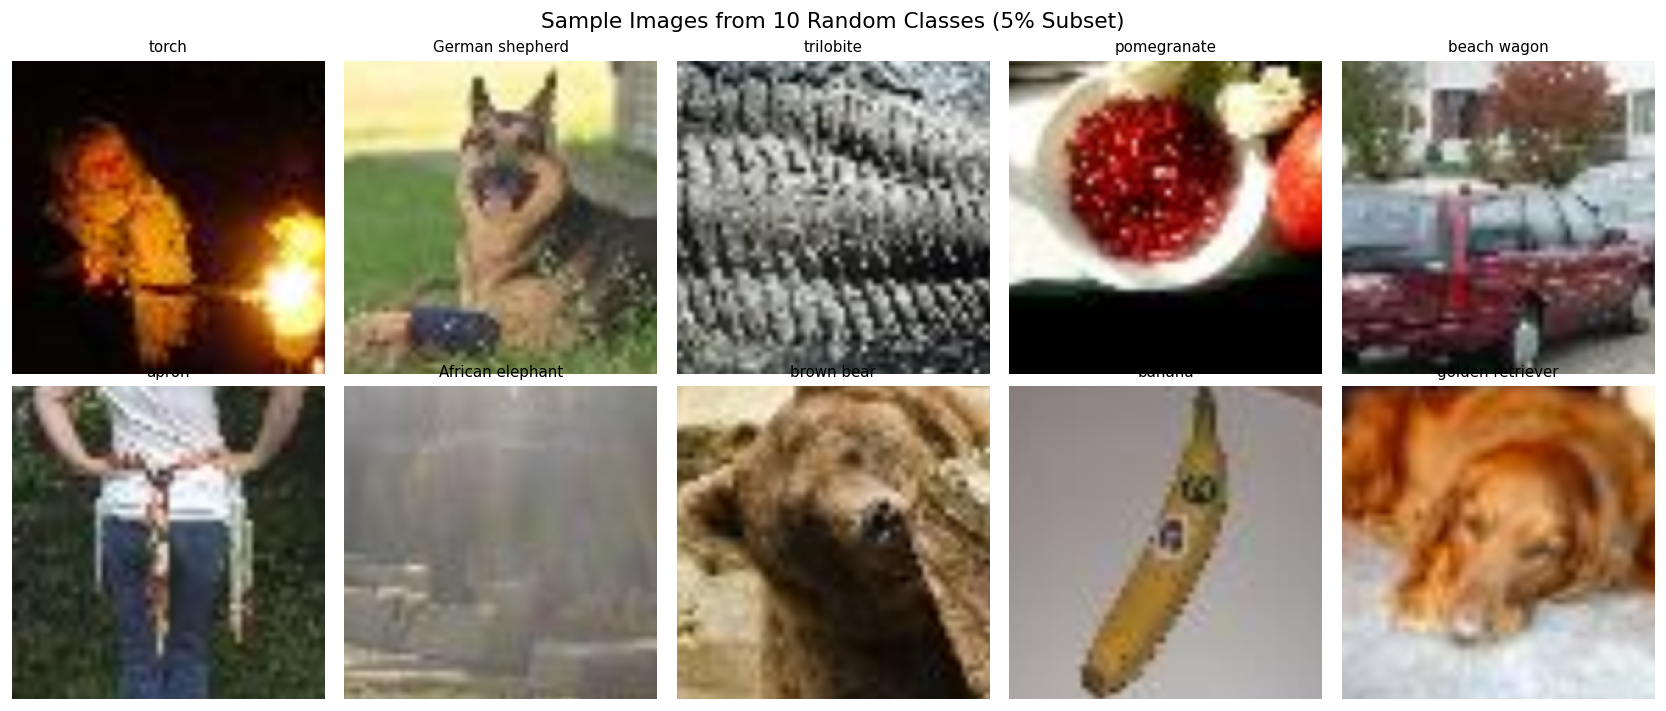

In [7]:
# Load human-readable class names from words.txt
words_path = TINY_IMAGENET_ROOT / "words.txt"
wnid_to_words = {}
if words_path.exists():
    with words_path.open() as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                wnid_to_words[parts[0]] = parts[1].split(",")[0].strip()

# ---- Sample images grid ----
vis_dataset = TinyImageNetSubset(
    TINY_IMAGENET_ROOT / "train", SUBSET_INDEX,
    transform=raw_transform, class_to_idx=class_to_idx,
)

rng_vis = random.Random(42)
selected_classes = rng_vis.sample(list(class_to_idx.keys()), 10)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, cid in zip(axes.flat, selected_classes):
    idxs = [i for i, e in enumerate(vis_dataset.entries) if e["class_id"] == cid]
    idx = rng_vis.choice(idxs)
    img_t, _, _ = vis_dataset[idx]
    ax.imshow(img_t.permute(1, 2, 0).numpy())
    ax.set_title(wnid_to_words.get(cid, cid)[:22], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample Images from 10 Random Classes (5% Subset)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()

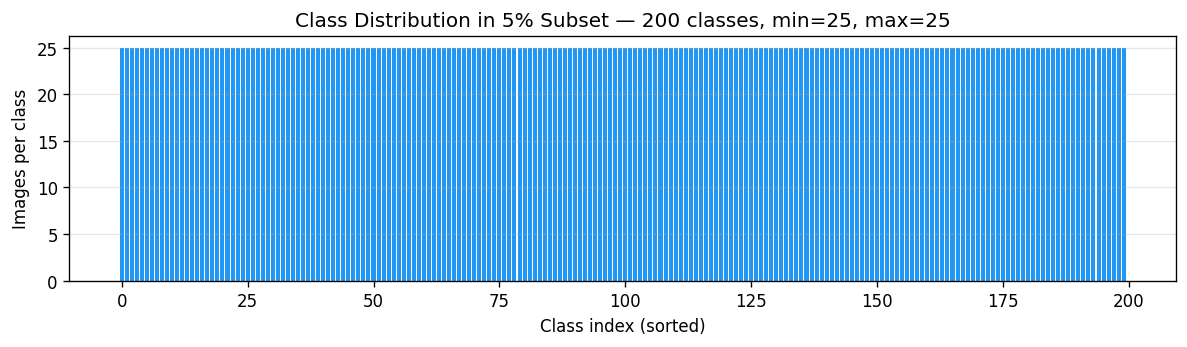

Total training images: 5000
Perfectly balanced (all classes equal): True


In [8]:
# ---- Class distribution histogram ----
class_counts = Counter(e["class_id"] for e in train_dataset.entries)
counts = sorted(class_counts.values())

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(counts)), counts, color="#2196F3")
ax.set_xlabel("Class index (sorted)")
ax.set_ylabel("Images per class")
ax.set_title(f"Class Distribution in 5% Subset — {len(class_counts)} classes, "
             f"min={min(counts)}, max={max(counts)}")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total training images: {sum(counts)}")
print(f"Perfectly balanced (all classes equal): {len(set(counts)) == 1}")

In [9]:
# ---- Image size check + channel statistics ----
rng_sz = random.Random(42)
size_sample_idxs = rng_sz.sample(range(len(vis_dataset)), min(500, len(vis_dataset)))
widths, heights = [], []
for i in size_sample_idxs:
    e = vis_dataset.entries[i]
    with Image.open(vis_dataset.root / e["image_path"]) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Image dimensions (sampled {len(widths)} images):")
print(f"  Width  — min: {min(widths)}, max: {max(widths)}, unique: {set(widths)}")
print(f"  Height — min: {min(heights)}, max: {max(heights)}, unique: {set(heights)}")

# Channel-wise mean/std on subset
ch_sum  = torch.zeros(3)
ch_sq   = torch.zeros(3)
n_px    = 0
for i in size_sample_idxs[:200]:
    img_t, _, _ = vis_dataset[i]
    ch_sum += img_t.sum(dim=(1, 2))
    ch_sq  += (img_t ** 2).sum(dim=(1, 2))
    n_px   += img_t.shape[1] * img_t.shape[2]

mean_ch = ch_sum / n_px
std_ch  = torch.sqrt(ch_sq / n_px - mean_ch ** 2)

print(f"\nChannel statistics (5% subset, 200 images):")
print(f"  Mean: R={mean_ch[0]:.4f}  G={mean_ch[1]:.4f}  B={mean_ch[2]:.4f}")
print(f"  Std:  R={std_ch[0]:.4f}  G={std_ch[1]:.4f}  B={std_ch[2]:.4f}")
print(f"\nImageNet defaults:")
print(f"  Mean: R=0.4850  G=0.4560  B=0.4060")
print(f"  Std:  R=0.2290  G=0.2240  B=0.2250")

Image dimensions (sampled 500 images):
  Width  — min: 64, max: 64, unique: {64}
  Height — min: 64, max: 64, unique: {64}

Channel statistics (5% subset, 200 images):
  Mean: R=0.4831  G=0.4400  B=0.3841
  Std:  R=0.2645  G=0.2518  B=0.2686

ImageNet defaults:
  Mean: R=0.4850  G=0.4560  B=0.4060
  Std:  R=0.2290  G=0.2240  B=0.2250


## 4. Baseline Model Setup

We use **ResNet-18 pretrained on ImageNet** as the backbone. The final fully-connected layer is replaced with a 200-way classifier for Tiny ImageNet. This architecture is suitable because:
- Standard and well-understood for image classification benchmarks
- ImageNet pretraining provides strong initial features, even for 64×64 images resized to 224×224
- Computationally affordable on a single RTX 4060 GPU

In [10]:
class ResNet18Baseline(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_feat = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_feat, num_classes)

    def forward(self, x, return_features=False):
        if not return_features:
            return self.backbone(x)
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        x = self.backbone.avgpool(x)
        features = torch.flatten(x, 1)
        logits = self.backbone.fc(features)
        return logits, features

model = ResNet18Baseline(NUM_CLASSES).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ResNet-18 adapted for Tiny ImageNet ({NUM_CLASSES} classes)")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Final layer:          {model.backbone.fc}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/bds/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:03<00:00, 12.7MB/s]


ResNet-18 adapted for Tiny ImageNet (200 classes)
Total parameters:     11,279,112
Trainable parameters: 11,279,112
Final layer:          Linear(in_features=512, out_features=200, bias=True)


## 5. Training Loop

Fine-tuning for **5 epochs** using **AdamW** (lr = 3×10⁻⁴, weight decay = 0.01) with **mixed-precision** training.  
The small dataset (5,000 images, ~79 batches at batch size 64) means each epoch is fast.

In [11]:
def compute_accuracy(outputs, targets, topk=(1,)):
    maxk = max(topk)
    _, pred = outputs.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1).expand_as(pred))
    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0)
        res.append(correct_k.mul_(100.0 / targets.size(0)).item())
    return res

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scaler    = GradScaler(enabled=torch.cuda.is_available())

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    model.train()
    rl, rc, rt = 0.0, 0.0, 0
    for images, targets, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        with autocast(enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        bs = targets.size(0)
        rl += loss.item() * bs
        rc += compute_accuracy(outputs, targets)[0] / 100.0 * bs
        rt += bs
    train_loss, train_acc = rl / rt, rc / rt

    # ---- Validate ----
    model.eval()
    vl, vc, vt = 0.0, 0.0, 0
    with torch.no_grad():
        for images, targets, _ in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, targets)
            bs = targets.size(0)
            vl += loss.item() * bs
            vc += compute_accuracy(outputs, targets)[0] / 100.0 * bs
            vt += bs
    val_loss, val_acc = vl / vt, vc / vt

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{EPOCHS}  |  "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%  |  "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%")

# Save checkpoint
torch.save(model.state_dict(), CHECKPOINTS_DIR / "resnet18_baseline_5pct.pth")
print(f"\nCheckpoint saved: {CHECKPOINTS_DIR / 'resnet18_baseline_5pct.pth'}")

/tmp/ipykernel_29152/1633632857.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=torch.cuda.is_available())
Epoch 1/5 [Train]:   0%|          | 0/79 [00:00<?, ?it/s]/tmp/ipykernel_29152/1633632857.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


Epoch 1/5  |  Train Loss: 4.8620  Acc: 7.00%  |  Val Loss: 3.9853  Acc: 14.94%


Epoch 2/5  |  Train Loss: 3.7880  Acc: 20.56%  |  Val Loss: 3.5432  Acc: 22.92%


Epoch 3/5  |  Train Loss: 3.2223  Acc: 30.58%  |  Val Loss: 3.0290  Acc: 31.04%


Epoch 4/5  |  Train Loss: 2.7768  Acc: 39.76%  |  Val Loss: 2.9315  Acc: 32.60%


Epoch 5/5  |  Train Loss: 2.4920  Acc: 44.56%  |  Val Loss: 2.6976  Acc: 37.15%

Checkpoint saved: /home/bds/compvis/checkpoints/resnet18_baseline_5pct.pth


## 6. Initial Results

We analyse the baseline from multiple angles: training dynamics, sample predictions, model calibration (ECE), corruption robustness, and representation geometry.

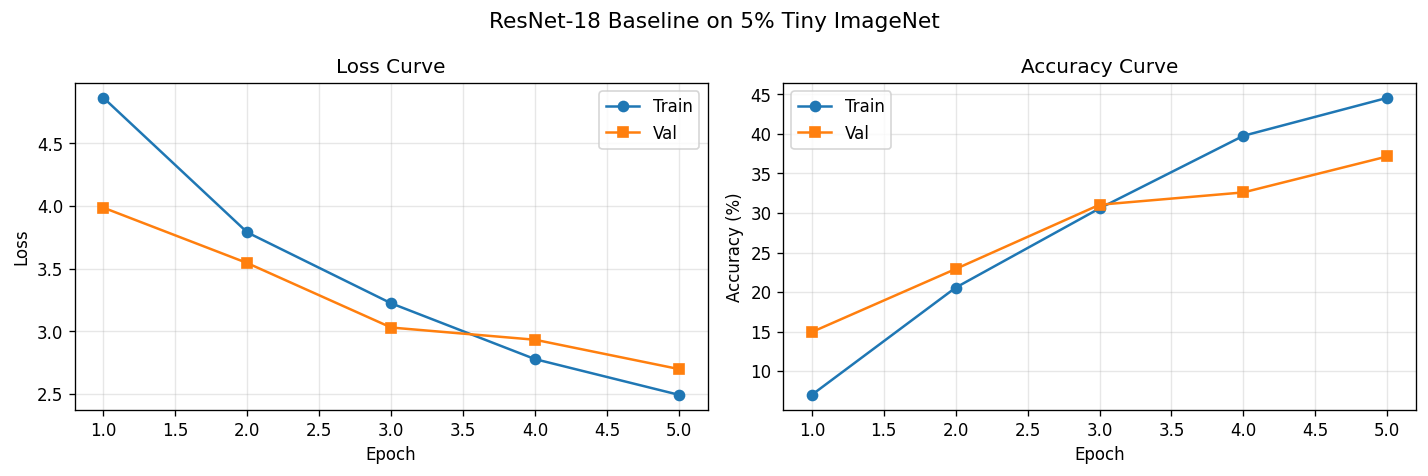

Final val accuracy: 37.15%


In [12]:
# ---- 6a. Loss and Accuracy Curves ----
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history["train_loss"], "o-", label="Train")
ax1.plot(epochs_range, history["val_loss"], "s-", label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss Curve"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history["train_acc"]], "o-", label="Train")
ax2.plot(epochs_range, [a*100 for a in history["val_acc"]], "s-", label="Val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy Curve"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("ResNet-18 Baseline on 5% Tiny ImageNet", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "loss_accuracy_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Final val accuracy: {history['val_acc'][-1]*100:.2f}%")

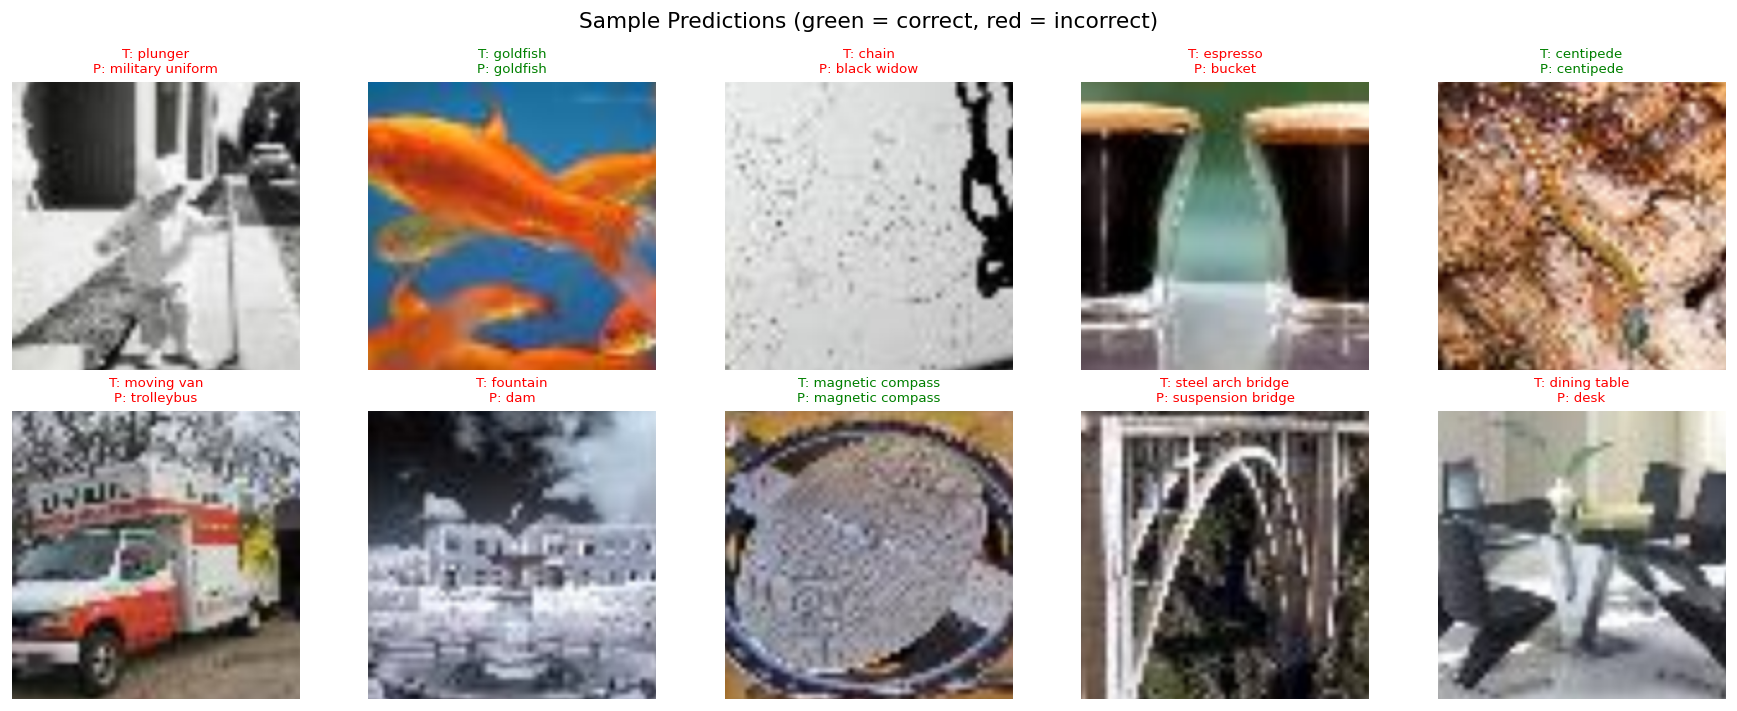

In [13]:
# ---- 6b. Sample Predictions ----
model.eval()
vis_val_raw = TinyImageNetVal(TINY_IMAGENET_ROOT, transform=raw_transform, class_to_idx=class_to_idx)
vis_val_norm = TinyImageNetVal(TINY_IMAGENET_ROOT, transform=val_transform, class_to_idx=class_to_idx)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
rng_pred = random.Random(123)
sample_idxs = rng_pred.sample(range(len(vis_val_raw)), 10)

for ax, si in zip(axes.flat, sample_idxs):
    img_raw, label, cid = vis_val_raw[si]
    img_norm, _, _ = vis_val_norm[si]
    with torch.no_grad():
        logits = model(img_norm.unsqueeze(0).to(DEVICE))
        pred_idx = logits.argmax(1).item()
    pred_cid = idx_to_class[pred_idx]
    true_name = wnid_to_words.get(cid, cid)[:20]
    pred_name = wnid_to_words.get(pred_cid, pred_cid)[:20]
    color = "green" if pred_idx == label else "red"
    ax.imshow(img_raw.permute(1, 2, 0).numpy())
    ax.set_title(f"T: {true_name}\nP: {pred_name}", fontsize=8, color=color)
    ax.axis("off")

plt.suptitle("Sample Predictions (green = correct, red = incorrect)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

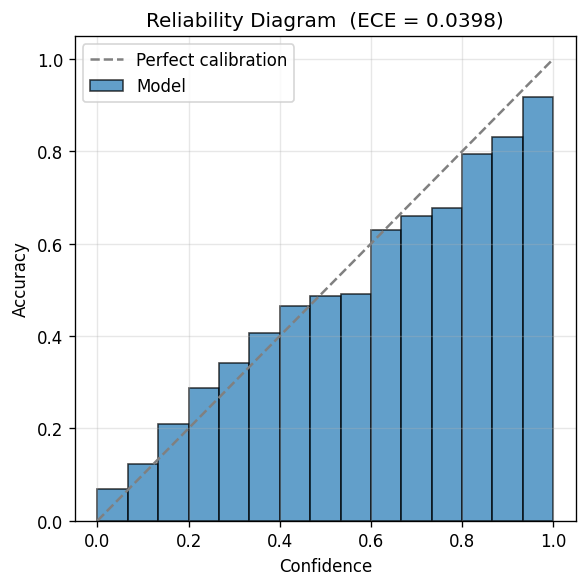

Expected Calibration Error (ECE): 0.0398


In [14]:
# ---- 6c. Calibration — Expected Calibration Error (ECE) ----
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for images, targets, _ in tqdm(val_loader, desc="Collecting logits"):
        logits = model(images.to(DEVICE))
        all_logits.append(logits.cpu())
        all_labels.append(targets)
all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

probs       = torch.softmax(all_logits, dim=1).numpy()
labels_np   = all_labels.numpy()
confidences = probs.max(axis=1)
predictions = probs.argmax(axis=1)
acc_arr     = (predictions == labels_np)

N_BINS = 15
bin_bounds = np.linspace(0, 1, N_BINS + 1)
ece = 0.0
bin_accs, bin_confs = [], []
for i in range(N_BINS):
    mask = (confidences > bin_bounds[i]) & (confidences <= bin_bounds[i + 1])
    if not np.any(mask):
        bin_accs.append(0); bin_confs.append(0)
        continue
    ba = acc_arr[mask].mean()
    bc = confidences[mask].mean()
    ece += np.abs(ba - bc) * (mask.sum() / len(labels_np))
    bin_accs.append(ba); bin_confs.append(bc)

bin_centers = (bin_bounds[:-1] + bin_bounds[1:]) / 2

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.bar(bin_centers, bin_accs, width=1/N_BINS, alpha=0.7, edgecolor="black", label="Model")
ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
ax.set_title(f"Reliability Diagram  (ECE = {ece:.4f})")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reliability_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Expected Calibration Error (ECE): {ece:.4f}")

Evaluating robustness (4 conditions)...


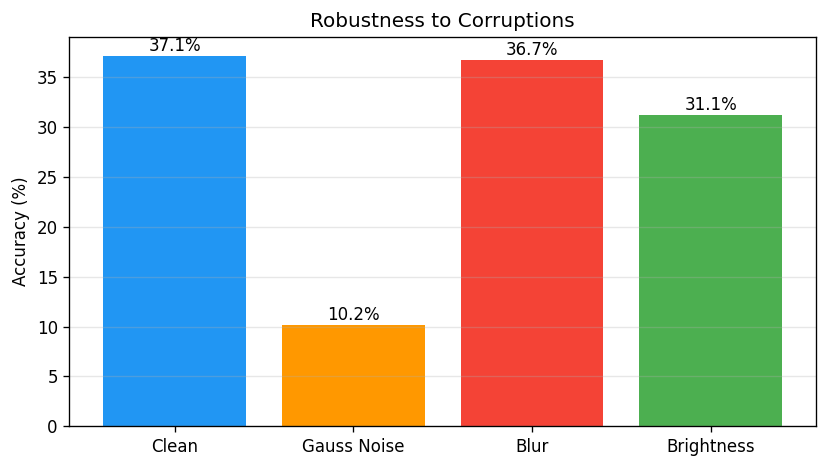

  Clean          : 37.15%
  Gauss Noise    : 10.17%
  Blur           : 36.72%
  Brightness     : 31.15%


In [15]:
# ---- 6d. Corruption Robustness ----
val_nonorm = TinyImageNetVal(TINY_IMAGENET_ROOT, transform=raw_transform, class_to_idx=class_to_idx)
val_nonorm_loader = DataLoader(val_nonorm, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS)

mean_t = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1).to(DEVICE)
std_t  = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1).to(DEVICE)

def eval_corruption(loader, corruption_fn=None):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, targets, _ in loader:
            images = images.to(DEVICE)
            if corruption_fn is not None:
                images = corruption_fn(images)
            images = (images - mean_t) / std_t
            targets = targets.to(DEVICE)
            correct += (model(images).argmax(1) == targets).sum().item()
            total += targets.size(0)
    return correct / total

print("Evaluating robustness (4 conditions)...")
robustness = {
    "Clean":     eval_corruption(val_nonorm_loader),
    "Gauss Noise": eval_corruption(val_nonorm_loader,
                        lambda x: (x + 0.1 * torch.randn_like(x)).clamp(0, 1)),
    "Blur":      eval_corruption(val_nonorm_loader,
                        lambda x: transforms.GaussianBlur(5)(x)),
    "Brightness": eval_corruption(val_nonorm_loader,
                        lambda x: (x + 0.2).clamp(0, 1)),
}

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2196F3", "#FF9800", "#F44336", "#4CAF50"]
bars = ax.bar(robustness.keys(), [v*100 for v in robustness.values()], color=colors)
for bar, v in zip(bars, robustness.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{v*100:.1f}%", ha="center", fontsize=10)
ax.set_ylabel("Accuracy (%)"); ax.set_title("Robustness to Corruptions")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "robustness_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

for name, acc in robustness.items():
    print(f"  {name:15s}: {acc*100:.2f}%")

Extracting features: 100%|██████████| 157/157 [00:22<00:00,  7.05it/s]


Feature matrix: (10000, 512)  (N samples x D features)


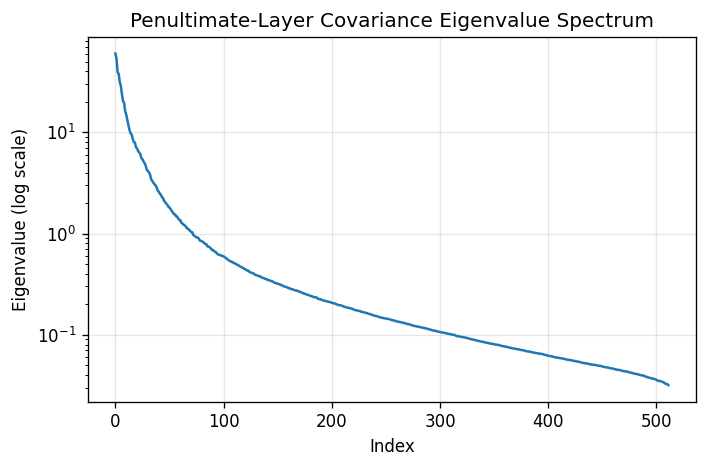

Top-5 eigenvalues: [60.0914 53.4349 39.5281 37.775  31.4849]
Effective rank (eigenvalue > 1% of max): 100 / 512


/home/bds/compvis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Linear probe accuracy (80/20 split): 42.00%


In [17]:
# ---- 6e. Representation Analysis ----
from sklearn.linear_model import LogisticRegression

model.eval()
all_feats, all_flabels = [], []
with torch.no_grad():
    for images, targets, _ in tqdm(val_loader, desc="Extracting features"):
        _, feats = model(images.to(DEVICE), return_features=True)
        all_feats.append(feats.cpu().numpy())
        all_flabels.append(targets.numpy())
feats_np  = np.concatenate(all_feats)
flabels   = np.concatenate(all_flabels)
print(f"Feature matrix: {feats_np.shape}  (N samples x D features)")

# -- Covariance eigenvalue spectrum --
feats_c = feats_np - feats_np.mean(axis=0, keepdims=True)
cov = np.cov(feats_c, rowvar=False)
eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(eigvals, linewidth=1.5)
ax.set_xlabel("Index"); ax.set_ylabel("Eigenvalue (log scale)")
ax.set_title("Penultimate-Layer Covariance Eigenvalue Spectrum")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eigenvalue_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Top-5 eigenvalues: {eigvals[:5].round(4)}")
eff_rank = (eigvals > 0.01 * eigvals[0]).sum()
print(f"Effective rank (eigenvalue > 1% of max): {eff_rank} / {len(eigvals)}")

# -- Linear probe --
n = len(flabels)
idx_perm = np.random.RandomState(42).permutation(n)
split = int(0.8 * n)
tr_i, te_i = idx_perm[:split], idx_perm[split:]

clf = LogisticRegression(max_iter=500, solver="lbfgs", n_jobs=-1)
clf.fit(feats_np[tr_i], flabels[tr_i])
probe_acc = clf.score(feats_np[te_i], flabels[te_i])
print(f"\nLinear probe accuracy (80/20 split): {probe_acc*100:.2f}%")

## 7. Diffusion Data Generation (Preview)

In Stage 2, we will generate class-conditional synthetic images using a **pretrained Stable Diffusion** model.  
No diffusion model training is required — we use the model as-is with text prompts derived from Tiny ImageNet class labels.

**Strategy:**
- Map each Tiny ImageNet class (WordNet ID) to a descriptive text prompt
- Generate ~200 synthetic images per class (**40,000 total**)
- Cache all generated images to `data/synthetic_sd/<class_id>/`
- Mix with real data at a **1:2** (real : synthetic) ratio during training

**Example prompt:** `"a photo of a goldfish, realistic, high quality"` for class `n01443537`

In [18]:
# Preview: class ID → text prompt mapping for Stable Diffusion
print("Sample class-to-prompt mapping (first 10 classes):\n")
for cid in sorted(class_to_idx.keys())[:10]:
    label = wnid_to_words.get(cid, cid)
    print(f"  {cid}  \u2192  \"a photo of a {label}, realistic, high quality\"")

print(f"\nPlanned: {NUM_CLASSES} classes \u00d7 200 images = {NUM_CLASSES * 200:,} synthetic images")
print(f"Storage: data/synthetic_sd/<class_id>/img_XXXX.png")

Sample class-to-prompt mapping (first 10 classes):

  n01443537  →  "a photo of a goldfish, realistic, high quality"
  n01629819  →  "a photo of a European fire salamander, realistic, high quality"
  n01641577  →  "a photo of a bullfrog, realistic, high quality"
  n01644900  →  "a photo of a tailed frog, realistic, high quality"
  n01698640  →  "a photo of a American alligator, realistic, high quality"
  n01742172  →  "a photo of a boa constrictor, realistic, high quality"
  n01768244  →  "a photo of a trilobite, realistic, high quality"
  n01770393  →  "a photo of a scorpion, realistic, high quality"
  n01774384  →  "a photo of a black widow, realistic, high quality"
  n01774750  →  "a photo of a tarantula, realistic, high quality"

Planned: 200 classes × 200 images = 40,000 synthetic images
Storage: data/synthetic_sd/<class_id>/img_XXXX.png


## 8. Combined Training (Preview)

In Stage 2, we will compare three pipelines and evaluate each beyond accuracy:

| Pipeline | Training Data | Purpose |
|----------|--------------|---------|
| **Baseline** | 5% real (5,000 images) | Low-data floor |
| **DiffusionBoost** | 5% real + synthetic from Stable Diffusion | Synthetic augmentation |
| **Ceiling** | 100% real (100,000 images) | Full-data upper bound |

The combined dataset loader below supports configurable real:synthetic mixing. In Stage 2, we will evaluate calibration (ECE), corruption robustness, and representation geometry (CKA, eigenvalue spectrum) across all pipelines. We will also examine whether synthetic utility varies across semantic categories, and whether class-level properties from this baseline can predict which classes benefit. Experiments will be replicated on a second lightweight architecture to test generalisability.

In [19]:
class CombinedRealSyntheticDataset(Dataset):
    """Mixes real and synthetic samples at a configurable ratio."""
    def __init__(self, real_ds, synth_ds, ratio=(1, 2)):
        self.real, self.synth = real_ds, synth_ds
        self.r, self.s = ratio
        self.total = self.r + self.s

    def __len__(self):
        return len(self.real) * self.total

    def __getitem__(self, idx):
        if idx % self.total < self.r:
            return self.real[(idx // self.total) % len(self.real)]
        return self.synth[(idx // self.total) % len(self.synth)]

print("CombinedRealSyntheticDataset ready for Stage 2.")
print(f"With 1:2 ratio, effective epoch = {len(train_dataset)} \u00d7 3 = {len(train_dataset)*3:,} samples")

# ---- Final Summary ----
print("\n" + "="*65)
print("  STAGE 1 PROOF-OF-CONCEPT SUMMARY")
print("="*65)
print(f"  Dataset:          Tiny ImageNet 5% ({len(train_dataset):,} train / {len(val_dataset):,} val)")
print(f"  Model:            ResNet-18 (pretrained, {trainable_params:,} params)")
print(f"  Epochs:           {EPOCHS}")
print(f"  Final Val Acc:    {history['val_acc'][-1]*100:.2f}%")
print(f"  ECE:              {ece:.4f}")
print(f"  Linear Probe Acc: {probe_acc*100:.2f}%")
print(f"  Clean Robustness: {robustness['Clean']*100:.2f}%")
print("="*65)

CombinedRealSyntheticDataset ready for Stage 2.
With 1:2 ratio, effective epoch = 5000 × 3 = 15,000 samples

  STAGE 1 PROOF-OF-CONCEPT SUMMARY
  Dataset:          Tiny ImageNet 5% (5,000 train / 10,000 val)
  Model:            ResNet-18 (pretrained, 11,279,112 params)
  Epochs:           5
  Final Val Acc:    37.15%
  ECE:              0.0398
  Linear Probe Acc: 42.00%
  Clean Robustness: 37.15%
